In [1]:
!pip install -U kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.2/69.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: kagglehub
    Found existing installation: kagglehub 0.3.13
    Uninstalling kagglehub-0.3.13:
      Successfully uninstalled kagglehub-0.3.13


In [2]:
import os

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parnianmalekian/anime-images")

print("Path to dataset files:", path)

100%|██████████| 160M/160M [00:02<00:00, 79.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/parnianmalekian/anime-images/versions/1


In [4]:
for root, dirs, files in os.walk(path):
    print(root, len(files))
    break

/root/.cache/kagglehub/datasets/parnianmalekian/anime-images/versions/1 0


In [5]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    image_size=(96, 96),
    batch_size=32,
    label_mode=None   # autoencoder ke liye
)

train_ds = train_ds.map(lambda x: x/255.0).prefetch(tf.data.AUTOTUNE)


Found 26220 files.


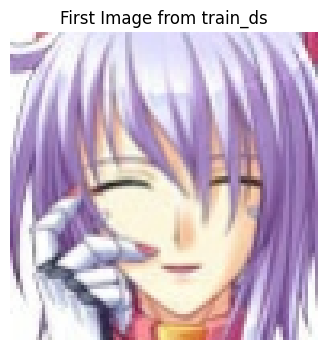

In [6]:
import matplotlib.pyplot as plt

# ek batch nikalo
batch = next(iter(train_ds))   # shape: (batch, 96, 96, 3)

# first image
img = batch[0]

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title("First Image from train_ds")
plt.show()

In [7]:
print(batch.shape)

(32, 96, 96, 3)


In [8]:
train_ds = train_ds.map(lambda x: (x * 2.0) - 1.0)

# Now Style GAN making

## Mapping Network (z → w)


```
z (noise 512)
   ↓
8-layer MLP
   ↓
w (style vector)
```



In [9]:
import tensorflow as tf
from tensorflow.keras import layers

class PixelNorm(layers.Layer):
    def __init__(self, epsilon=1e-8):
        super().__init__()
        self.epsilon = epsilon

    def call(self, x):
        return x / tf.sqrt(tf.reduce_mean(tf.square(x), axis=-1, keepdims=True) + self.epsilon)


In [10]:
def build_mapping_network(z_dim=512, w_dim=512, num_layers=8):
    z = layers.Input(shape=(z_dim,))
    x = PixelNorm()(z)

    for _ in range(num_layers):
        x = layers.Dense(w_dim)(x)
        x = layers.LeakyReLU(0.2)(x)

    return tf.keras.Model(z, x, name="MappingNetwork")


In [11]:
mapping = build_mapping_network()

z = tf.random.normal([1, 512])
w = mapping(z)

print("z shape:", z.shape)
print("w shape:", w.shape)


z shape: (1, 512)
w shape: (1, 512)


# Style Block + AdaIN (StyleGAN ka asli magic)

In [12]:
class NoiseInjection(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.weight = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        noise = tf.random.normal(tf.shape(x))
        return x + noise * self.weight


In [13]:
# AdaIN(x, w) = scale(w) * norm(x) + bias(w)
class AdaIN(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.scale = tf.keras.layers.Dense(channels)
        self.bias  = tf.keras.layers.Dense(channels)

    def call(self, x, w):
        mean, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x_norm = (x - mean) / tf.sqrt(var + 1e-8)

        s = self.scale(w)[:, None, None, :]
        b = self.bias(w)[:, None, None, :]
        return s * x_norm + b


In [14]:
class StyleConv(tf.keras.layers.Layer): # <- This class is use in Generator
    def __init__(self, out_channels):
        super().__init__()
        self.conv = tf.keras.layers.Conv2D(
            out_channels, 3, padding="same"
        )
        self.noise = NoiseInjection() # <- Noise vali class
        self.adain = AdaIN(out_channels) # <-- class adain
        self.act = tf.keras.layers.LeakyReLU(0.2) # <- activation function relu

    def call(self, x, w):
        x = self.conv(x)
        x = self.noise(x)
        x = self.adain(x, w)
        return self.act(x)
# testing done (1, 16, 16, 128)

# Style-based Generator


```
Const (6×6×512)
   ↓ StyleConv(w)
   ↓ Upsample
   ↓ StyleConv(w)
   ↓ ...
   ↓ 96×96 RGB image
```



In [15]:
class ConstantInput(tf.keras.layers.Layer):
    def __init__(self, channels=512):
        super().__init__()
        self.channels = channels

    def build(self, input_shape):
        self.const = self.add_weight(
            shape=(1, 6, 6, self.channels),
            initializer="ones",
            trainable=True
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        return tf.tile(self.const, [batch_size, 1, 1, 1])


In [16]:
def build_generator(w_dim=512):
    w = tf.keras.Input(shape=(w_dim,))

    x = ConstantInput(512)(w)

    x = StyleConv(512)(x, w)

    x = tf.keras.layers.UpSampling2D()(x)
    x = StyleConv(256)(x, w)

    x = tf.keras.layers.UpSampling2D()(x)
    x = StyleConv(128)(x, w)

    x = tf.keras.layers.UpSampling2D()(x)
    x = StyleConv(64)(x, w)

    x = tf.keras.layers.UpSampling2D()(x)
    x = StyleConv(32)(x, w)

    rgb = tf.keras.layers.Conv2D(3, 1, padding="same", activation="tanh")(x)

    return tf.keras.Model(w, rgb, name="StyleGenerator")


In [17]:
gen = build_generator()
mapping = build_mapping_network()

z = tf.random.normal([2, 512])
w = mapping(z)

fake_imgs = gen(w)
print(fake_imgs.shape)


(2, 96, 96, 3)


# Simple Discriminator


```
96×96×3
 ↓
48×48×64
 ↓
24×24×128
 ↓
12×12×256
 ↓
6×6×512
 ↓
Dense(1)

```



In [18]:
def build_discriminator():
    img = tf.keras.Input(shape=(96, 96, 3))

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding="same")(img)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(512, 4, strides=2, padding="same")(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Flatten()(x)
    out = tf.keras.layers.Dense(1)(x)  # no sigmoid

    return tf.keras.Model(img, out, name="Discriminator")


In [19]:
disc = build_discriminator()

fake = tf.random.normal([2, 96, 96, 3])
score = disc(fake)

print(score.shape)


(2, 1)


## Loss Function making

In [20]:
def d_loss_fn(real_logits, fake_logits):
    real_loss = tf.nn.softplus(-real_logits)   # log(1 + e^-D(x))
    fake_loss = tf.nn.softplus(fake_logits)    # log(1 + e^D(G(z)))
    return tf.reduce_mean(real_loss + fake_loss)

def g_loss_fn(fake_logits):
    return tf.reduce_mean(tf.nn.softplus(-fake_logits))

g_opt = tf.keras.optimizers.Adam(
    learning_rate=2e-4, beta_1=0.0, beta_2=0.99
)

d_opt = tf.keras.optimizers.Adam(
    learning_rate=2e-4, beta_1=0.0, beta_2=0.99
)

# 👇Drop models

In [21]:
mapping = build_mapping_network()
generator = build_generator()
discriminator = build_discriminator()

# stepup training

In [22]:
@tf.function
def train_step(real_imgs):
    batch_size = tf.shape(real_imgs)[0]
    z = tf.random.normal([batch_size, 512])

    # ------------------
    # Train Discriminator
    # ------------------
    with tf.GradientTape() as d_tape:
        w = mapping(z)
        fake_imgs = generator(w)

        real_logits = discriminator(real_imgs)
        fake_logits = discriminator(fake_imgs)

        d_loss = d_loss_fn(real_logits, fake_logits)

    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # ------------------
    # Train Generator + Mapping
    # ------------------
    with tf.GradientTape() as g_tape:
        w = mapping(z)
        fake_imgs = generator(w)
        fake_logits = discriminator(fake_imgs)

        g_loss = g_loss_fn(fake_logits)

    g_vars = generator.trainable_variables + mapping.trainable_variables
    g_grads = g_tape.gradient(g_loss, g_vars)
    g_opt.apply_gradients(zip(g_grads, g_vars))

    return d_loss, g_loss


In [23]:
epochs = 30

for epoch in range(epochs):
    for step, real_imgs in enumerate(train_ds):
        d_loss, g_loss = train_step(real_imgs)

        if step % 100 == 0:
            print(
                f"Epoch {epoch+1} | Step {step} | "
                f"D Loss: {d_loss.numpy():.3f} | G Loss: {g_loss.numpy():.3f}"
            )


Epoch 1 | Step 0 | D Loss: 1.391 | G Loss: 0.678
Epoch 1 | Step 100 | D Loss: 1.346 | G Loss: 1.188
Epoch 1 | Step 200 | D Loss: 1.090 | G Loss: 1.204
Epoch 1 | Step 300 | D Loss: 0.793 | G Loss: 2.148
Epoch 1 | Step 400 | D Loss: 1.123 | G Loss: 1.763
Epoch 1 | Step 500 | D Loss: 0.854 | G Loss: 1.347
Epoch 1 | Step 600 | D Loss: 0.917 | G Loss: 2.016
Epoch 1 | Step 700 | D Loss: 1.572 | G Loss: 3.027
Epoch 1 | Step 800 | D Loss: 1.238 | G Loss: 3.501
Epoch 2 | Step 0 | D Loss: 1.020 | G Loss: 4.008
Epoch 2 | Step 100 | D Loss: 0.752 | G Loss: 1.729
Epoch 2 | Step 200 | D Loss: 0.782 | G Loss: 1.599
Epoch 2 | Step 300 | D Loss: 0.753 | G Loss: 1.793
Epoch 2 | Step 400 | D Loss: 0.627 | G Loss: 1.945
Epoch 2 | Step 500 | D Loss: 0.970 | G Loss: 3.431
Epoch 2 | Step 600 | D Loss: 0.322 | G Loss: 3.201
Epoch 2 | Step 700 | D Loss: 0.696 | G Loss: 1.946
Epoch 2 | Step 800 | D Loss: 0.600 | G Loss: 2.771
Epoch 3 | Step 0 | D Loss: 3.069 | G Loss: 2.910
Epoch 3 | Step 100 | D Loss: 0.544 | 

# Testing Gan

In [25]:
import matplotlib.pyplot as plt

def show_samples(n=5):
    z = tf.random.normal([n, 512])
    w = mapping(z)
    imgs = generator(w)

    imgs = (imgs + 1.0) / 2.0  # back to [0,1]

    plt.figure(figsize=(10,2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(imgs[i])
        plt.axis("off")
    plt.show()

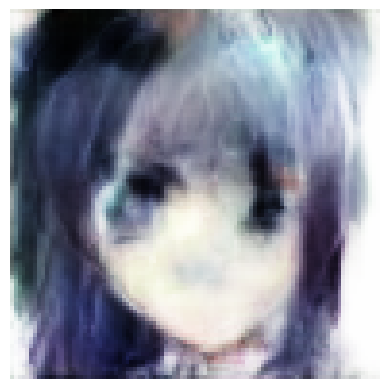

In [31]:

tf.random.set_seed(seed)
z = tf.random.normal([1, 512])
w = mapping(z)
img = generator(w)[0]
img = (img + 1.0) / 2.0

plt.imshow(img)
plt.axis("off")
plt.show()